In [ ]:
from google.colab import files

uploaded = files.upload()


Saving bankloans.csv to bankloans.csv


  Variable Name T-Statistic   P-Value
0       address   -4.430552  0.000011
1           age   -3.698933  0.000234
2      creddebt    6.479087       0.0
3       debtinc   11.140936       0.0
4            ed    3.153507  0.001682
5        employ   -7.921358       0.0
6        income   -2.643292  0.008395
7       othdebt    3.707297  0.000226


/tmp/ipykernel_7992/3349012377.py:75: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bankloans_existing[bankloans_existing['default']==0][num_variable], label='Not Default', color='b', hist=True, norm_hist=False)
/tmp/ipykernel_7992/3349012377.py:76: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(

These variables need bucketing - creddebt, othdebt, debtinc, employ, income 
   VIF Factor   features
0   36.910987  Intercept
1    1.561802    address
2    2.037593        age
3    2.628899   creddebt
4    3.910509    debtinc
5    1.287345         ed
6    2.401544     employ
7    5.121585     income
8    4.562072    othdebt
Optimization terminated successfully.
         Current function value: 0.425391
         Iterations 7
AUC is -> 0.8408309575716921
The Gini Index for the model built on the Train Data is :  0.6816619151433843
The Gini Index for the model built on the Test Data is :  0.7665103308404106


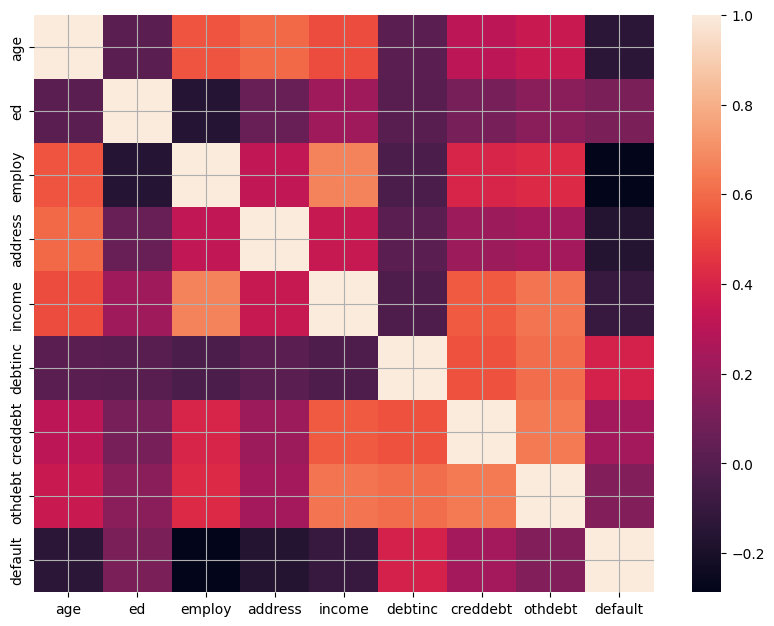

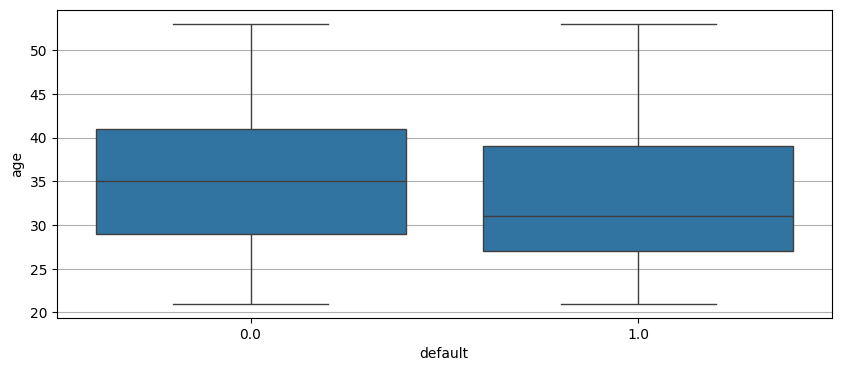

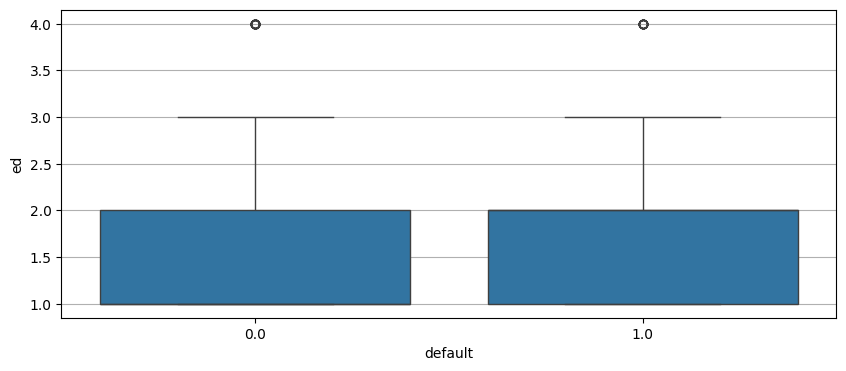

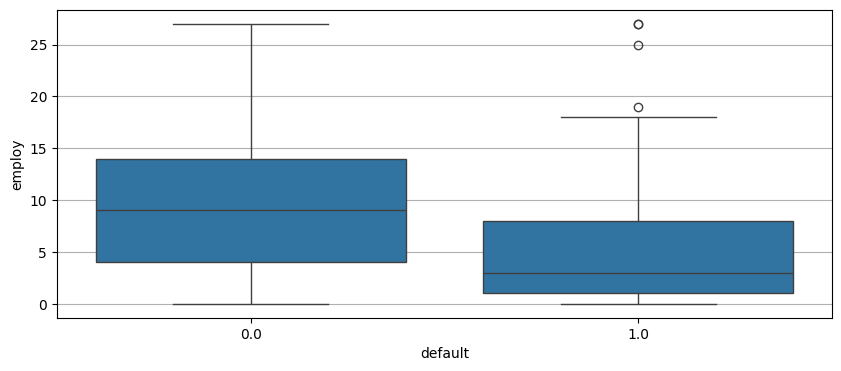

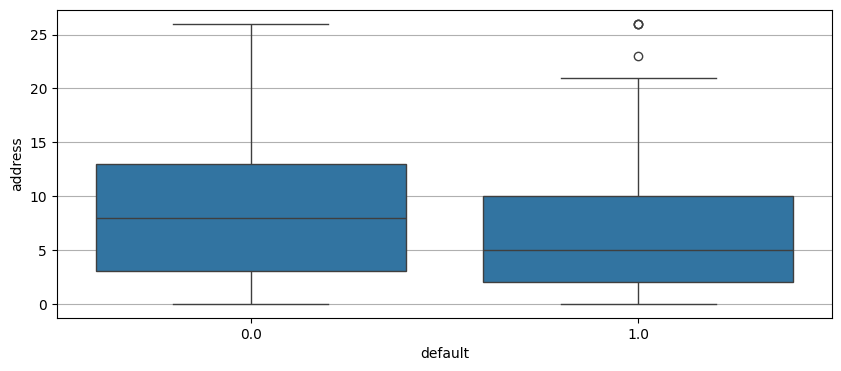

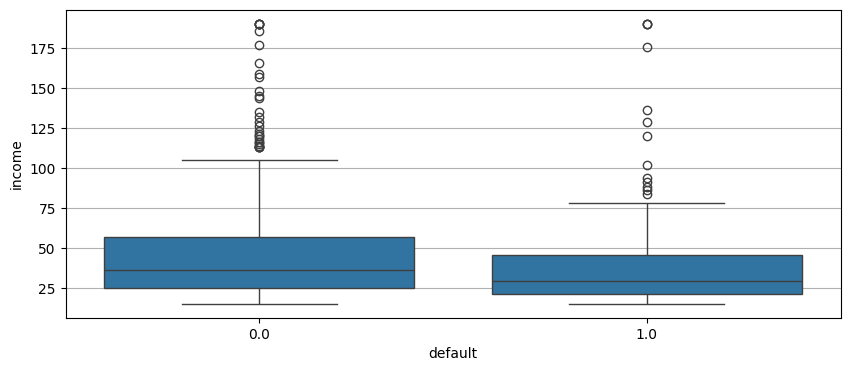

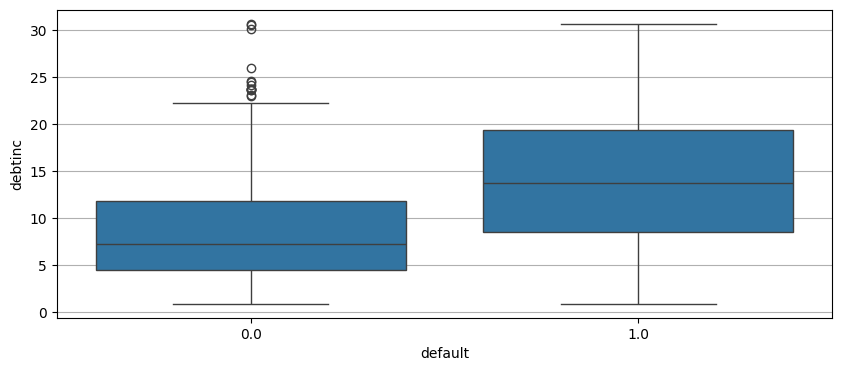

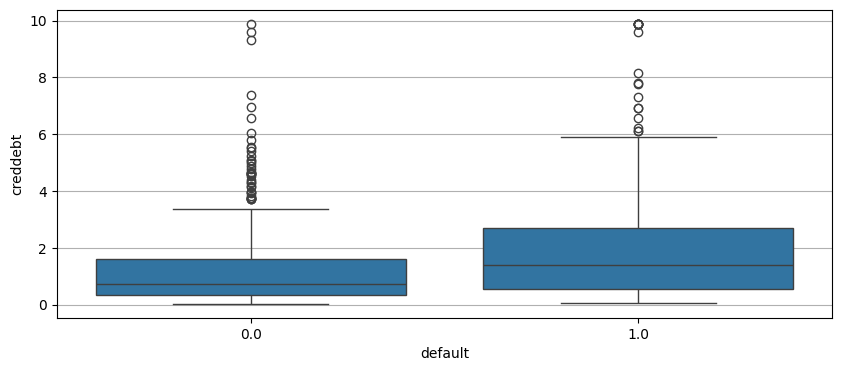

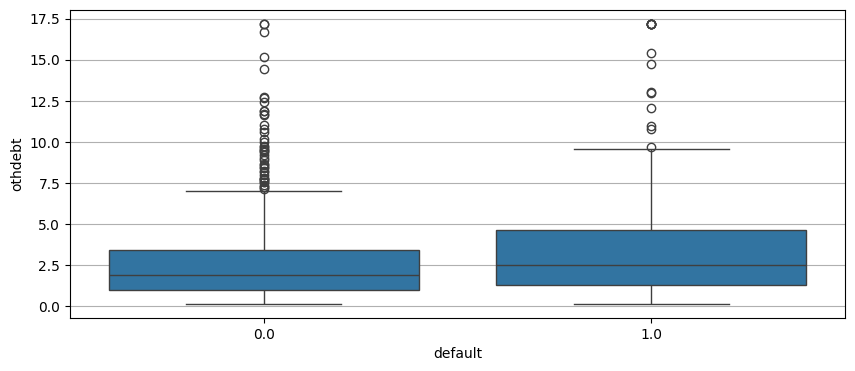

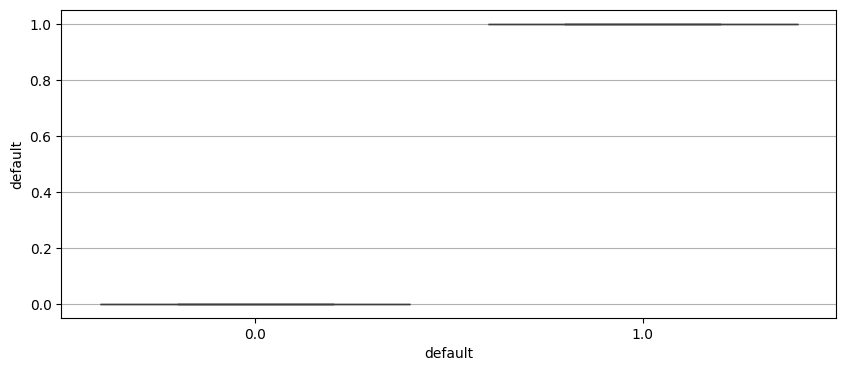

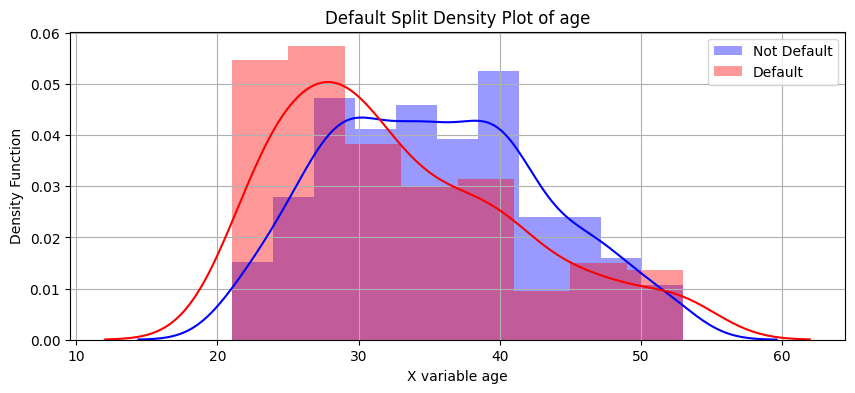

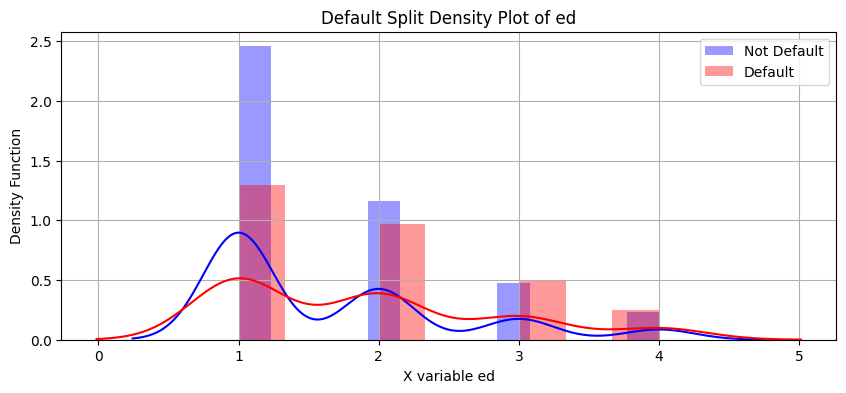

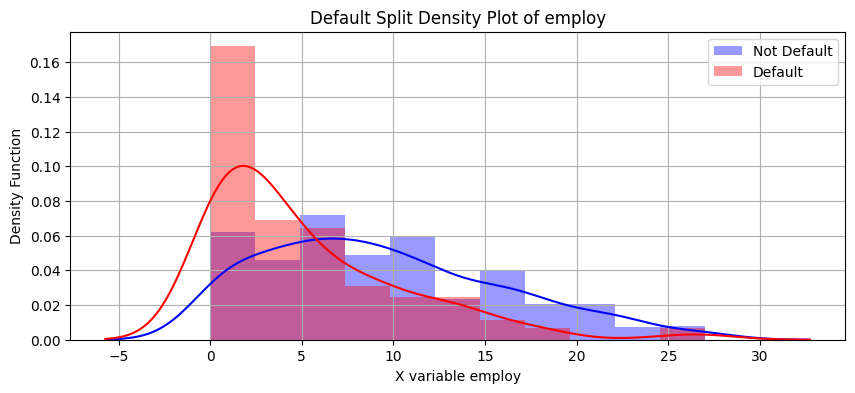

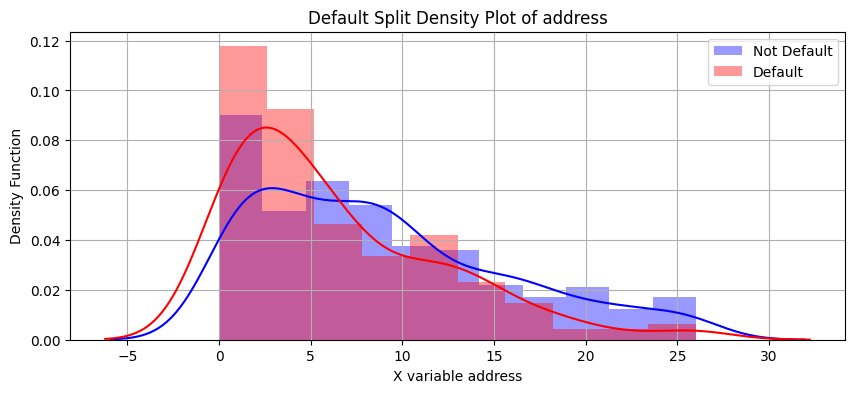

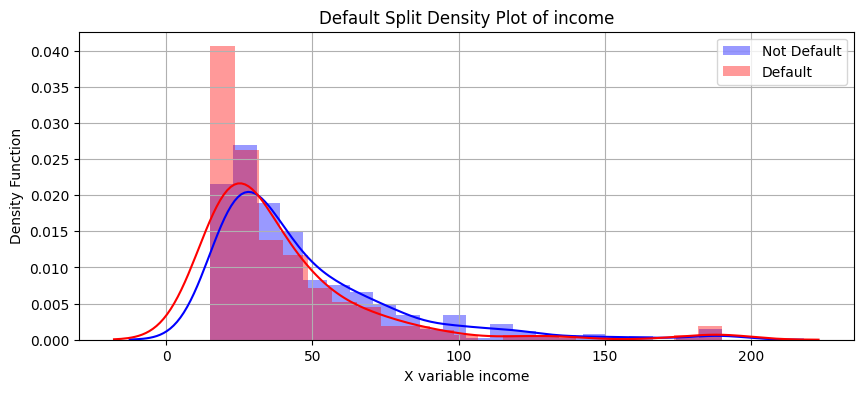

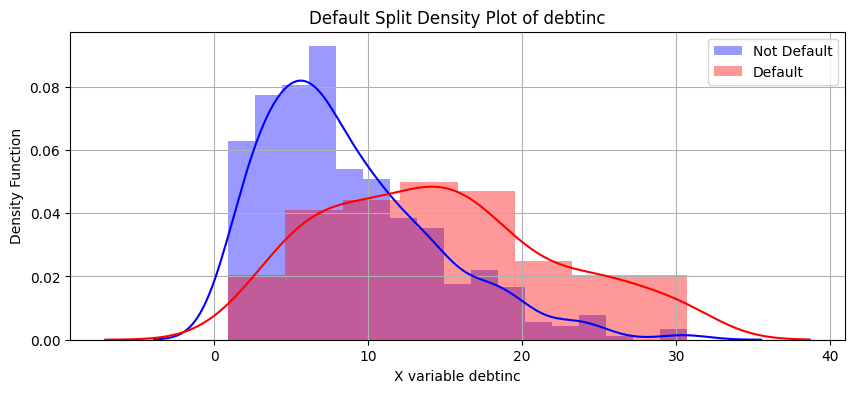

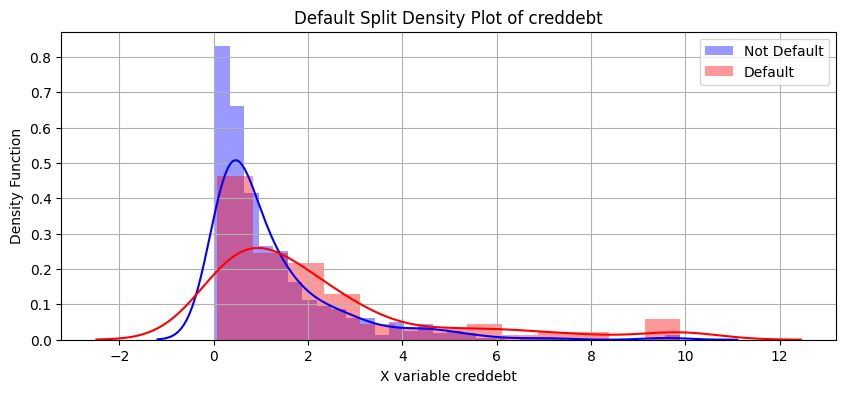

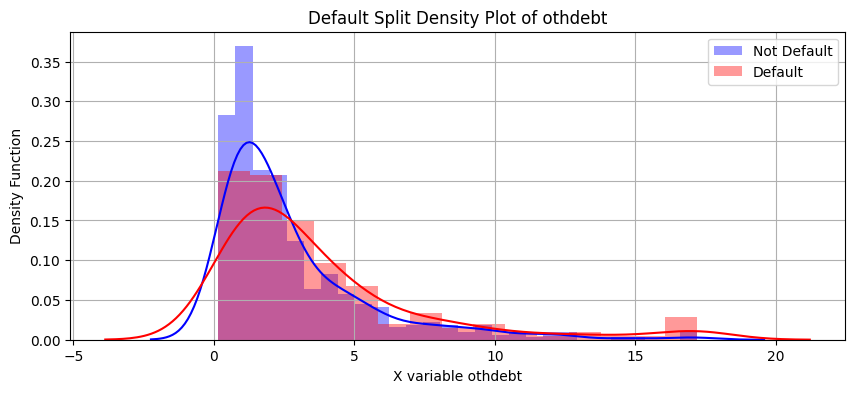

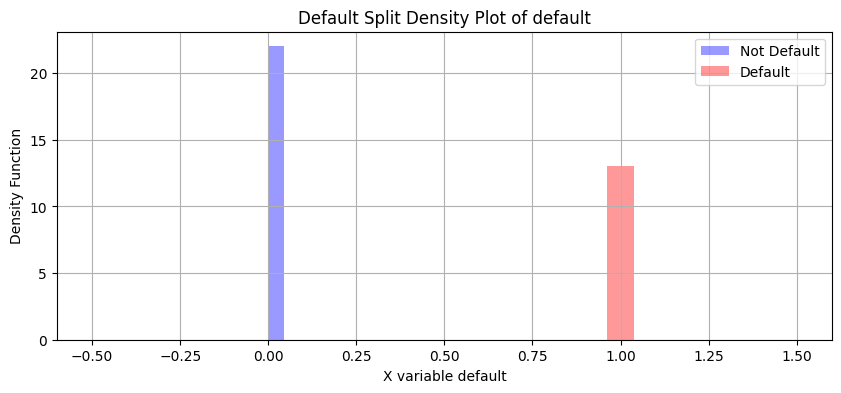

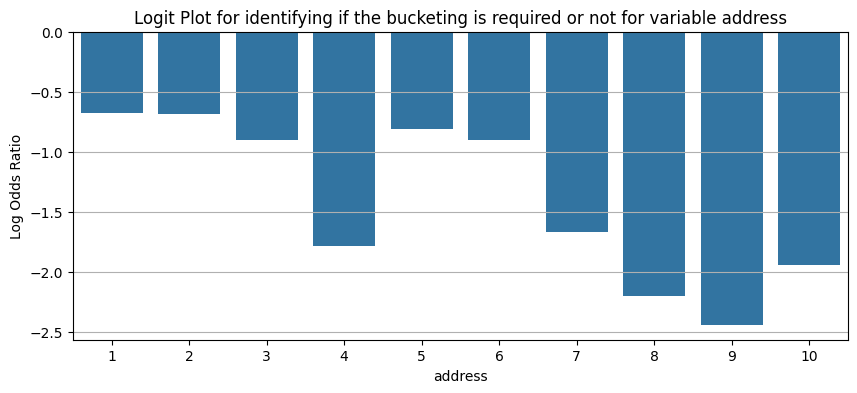

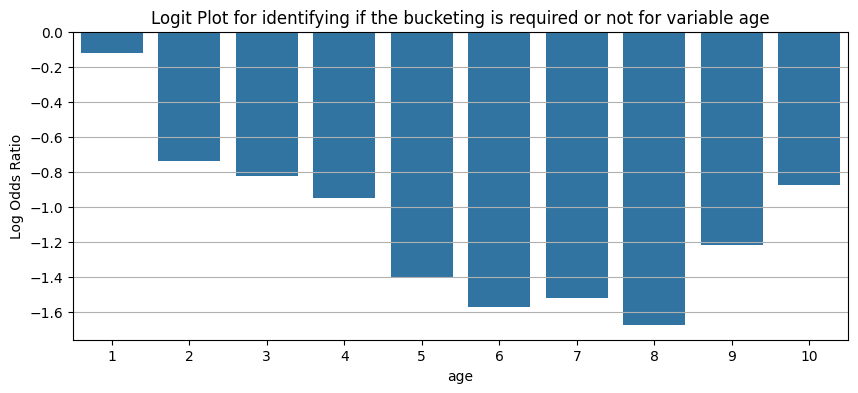

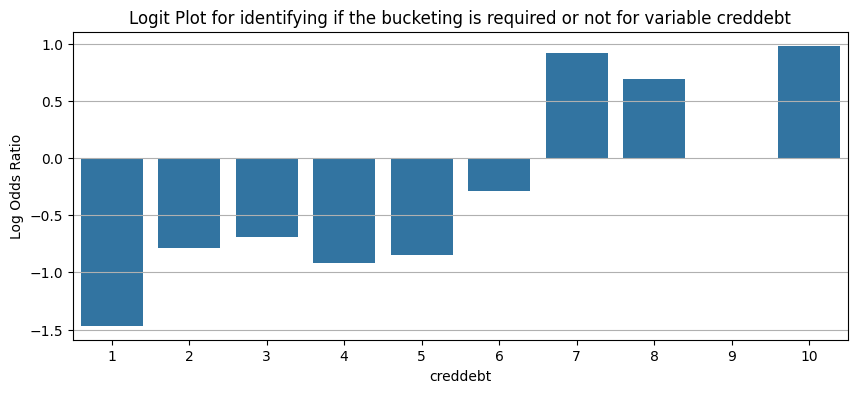

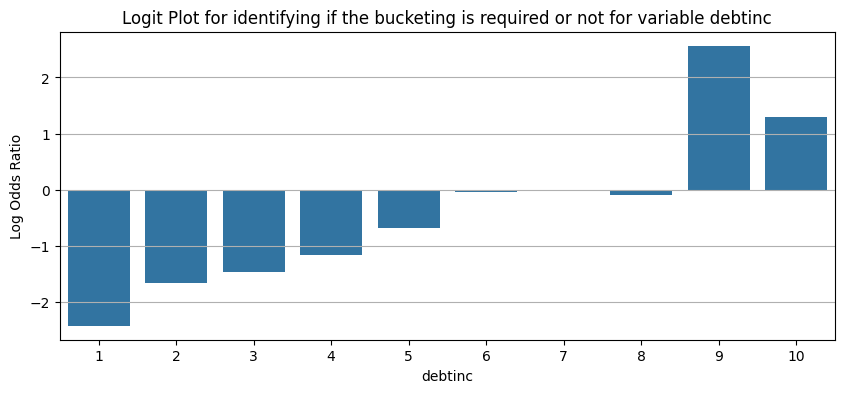

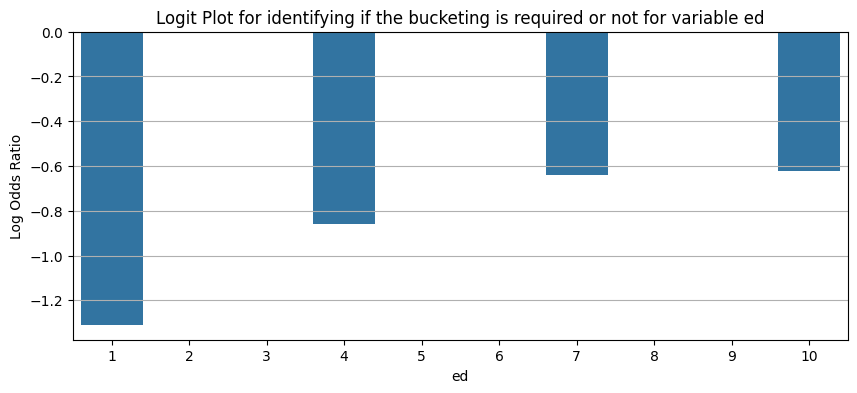

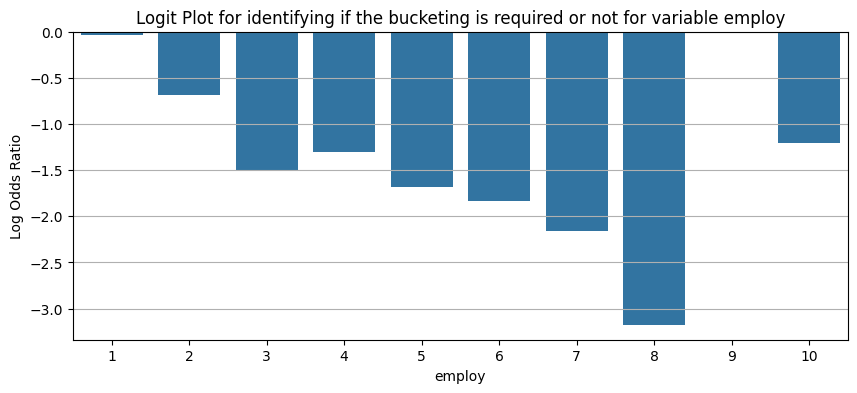

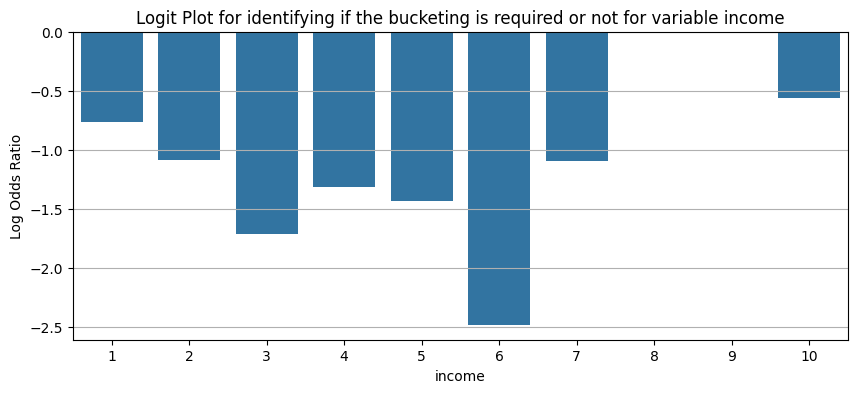

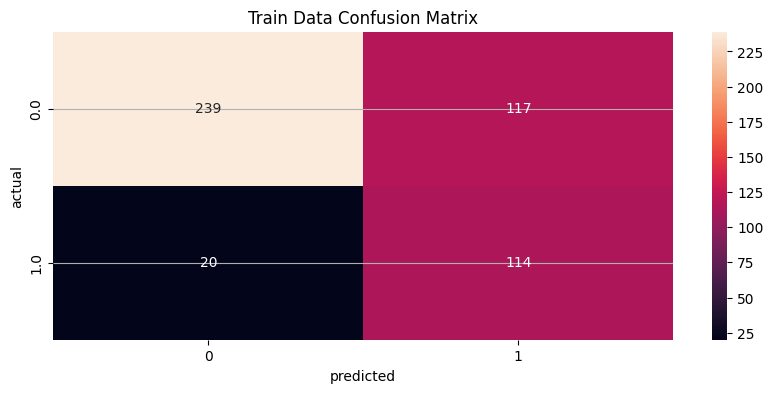

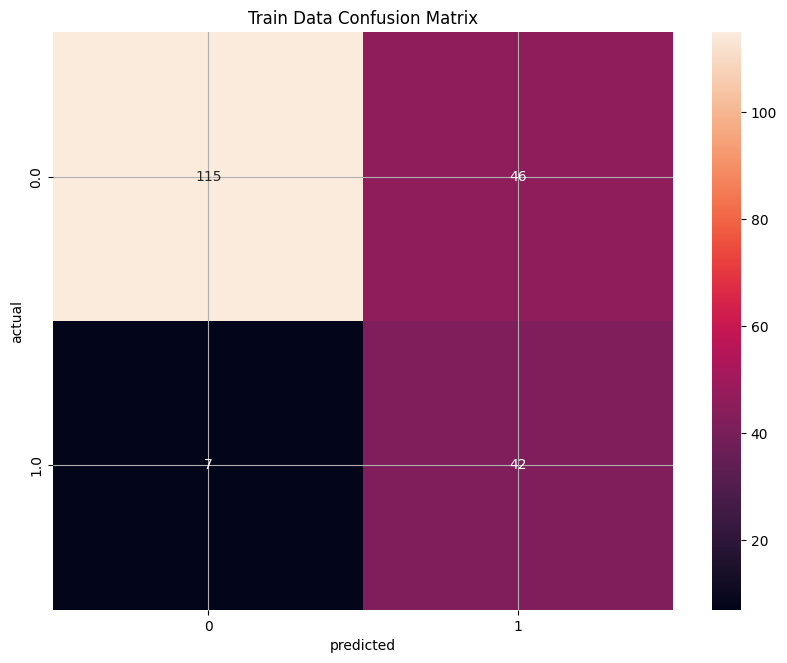

,Deciles,actual
Deciles,,
9,441,36.0
8,392,28.0
7,343,26.0
6,294,15.0
5,245,13.0
4,196,6.0
3,147,5.0
2,98,3.0
1,49,2.0


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as sm
import scipy.stats as stats
#import pandas_profiling

%matplotlib inline
plt.rcParams['figure.figsize'] = 10, 7.5
plt.rcParams['axes.grid'] = True
plt.gray()

from matplotlib.backends.backend_pdf import PdfPages

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices
bankloans=pd.read_csv('bankloans.csv')
len(bankloans)
## Generic functions for data explorations
def var_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.sum(), x.mean(), x.median(),  x.std(), x.var(), x.min(), x.dropna().quantile(0.01), x.dropna().quantile(0.05),x.dropna().quantile(0.10),x.dropna().quantile(0.25),x.dropna().quantile(0.50),x.dropna().quantile(0.75), x.dropna().quantile(0.90),x.dropna().quantile(0.95), x.dropna().quantile(0.99),x.max()],
                  index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'MIN', 'P1' , 'P5' ,'P10' ,'P25' ,'P50' ,'P75' ,'P90' ,'P95' ,'P99' ,'MAX'])


def cat_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.value_counts()],
                  index=['N', 'NMISS', 'ColumnsNames'])

def create_dummies( df, colname ):
    col_dummies = pd.get_dummies(df[colname], prefix=colname)
    col_dummies.drop(col_dummies.columns[0], axis=1, inplace=True)
    df = pd.concat([df, col_dummies], axis=1)
    df.drop( colname, axis = 1, inplace = True )
    return df

#Handling outliers
def outlier_capping(x):
    x = x.clip(upper=x.quantile(0.99))
    x = x.clip(lower=x.quantile(0.01))
    return x

def Missing_imputation(x):
    x = x.fillna(x.mean())
    return x
bankloans.apply(lambda x: var_summary(x)).T
bankloans_existing = bankloans[bankloans.default.isnull()==0]
bankloans_new = bankloans[bankloans.default.isnull()==1]
bankloans_existing=bankloans_existing.apply(lambda x: outlier_capping(x))
bankloans_existing=bankloans_existing.apply(lambda x: Missing_imputation(x))
numeric_var_names=[key for key in dict(bankloans.dtypes) if dict(bankloans.dtypes)[key] in ['float64', 'int64', 'float32', 'int32']]
cat_var_names=[key for key in dict(bankloans.dtypes) if dict(bankloans.dtypes)[key] in ['object']]
sns.heatmap(bankloans_existing.corr())
bp = PdfPages('BoxPlots with default Split.pdf')

for num_variable in numeric_var_names:
    fig,axes = plt.subplots(figsize=(10,4))
    sns.boxplot(x='default', y=num_variable, data = bankloans_existing)
    bp.savefig(fig)
bp.close()
tstats_df = pd.DataFrame()
for num_variable in bankloans_existing.columns.difference(['default']):
    tstats=stats.ttest_ind(bankloans_existing[bankloans_existing.default==1][num_variable],bankloans_existing[bankloans_existing.default==0][num_variable])
    temp = pd.DataFrame([num_variable, tstats[0], tstats[1]]).T
    temp.columns = ['Variable Name', 'T-Statistic', 'P-Value']
    tstats_df = pd.concat([tstats_df, temp], axis=0, ignore_index=True)
print(tstats_df)
for num_variable in numeric_var_names:
    fig,axes = plt.subplots(figsize=(10,4))
    #sns.distplot(hrdf[num_variable], kde=False, color='g', hist=True)
    sns.distplot(bankloans_existing[bankloans_existing['default']==0][num_variable], label='Not Default', color='b', hist=True, norm_hist=False)
    sns.distplot(bankloans_existing[bankloans_existing['default']==1][num_variable], label='Default', color='r', hist=True, norm_hist=False)
    plt.xlabel(str("X variable ") + str(num_variable) )
    plt.ylabel('Density Function')
    plt.title(str('Default Split Density Plot of ')+str(num_variable))
    plt.legend()
bp = PdfPages('Transformation Plots.pdf')

for num_variable in bankloans_existing.columns.difference(['default']):
    binned = pd.cut(bankloans_existing[num_variable], bins=10, labels=list(range(1,11)))
    binned = binned.dropna()
    ser = bankloans_existing.groupby(binned)['default'].sum() / (bankloans_existing.groupby(binned)['default'].count()-bankloans_existing.groupby(binned)['default'].sum())
    ser = np.log(ser)
    fig,axes = plt.subplots(figsize=(10,4))
    sns.barplot(x=ser.index,y=ser)
    plt.ylabel('Log Odds Ratio')
    plt.title(str('Logit Plot for identifying if the bucketing is required or not for variable ') + str(num_variable))
    bp.savefig(fig)

bp.close()
print('These variables need bucketing - creddebt, othdebt, debtinc, employ, income ')
bankloans_existing.columns
bankloans_existing[['creddebt', 'othdebt', 'debtinc', 'employ','income' ]].describe(percentiles=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]).T
features = "+".join(bankloans_existing.columns.difference(['default']))
a,b = dmatrices(formula_like='default ~ '+ features, data = bankloans_existing, return_type='dataframe')

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(b.values, i) for i in range(b.shape[1])]
vif["features"] = b.columns

print(vif)
train_features = bankloans_existing.columns.difference(['default'])
train_X, test_X = train_test_split(bankloans_existing, test_size=0.3, random_state=42)
train_X.columns
logreg = sm.logit(formula='default ~ ' + "+".join(train_features), data=train_X)
result = logreg.fit()
summ = result.summary()
sum
AUC = metrics.roc_auc_score(train_X['default'], result.predict(train_X))
print('AUC is -> ' + str(AUC))
train_gini = 2*metrics.roc_auc_score(train_X['default'], result.predict(train_X)) - 1
print("The Gini Index for the model built on the Train Data is : ", train_gini)

test_gini = 2*metrics.roc_auc_score(test_X['default'], result.predict(test_X)) - 1
print("The Gini Index for the model built on the Test Data is : ", test_gini)
train_predicted_prob = pd.DataFrame(result.predict(train_X))
train_predicted_prob.columns = ['prob']
train_actual = train_X['default']
# making a DataFrame with actual and prob columns
train_predict = pd.concat([train_actual, train_predicted_prob], axis=1)
train_predict.columns = ['actual','prob']

test_predicted_prob = pd.DataFrame(result.predict(test_X))
test_predicted_prob.columns = ['prob']
test_actual = test_X['default']
# making a DataFrame with actual and prob columns
test_predict = pd.concat([test_actual, test_predicted_prob], axis=1)
test_predict.columns = ['actual','prob']

## Intuition behind ROC curve - predicted probability as a tool for separating the '1's and '0's
def cut_off_calculation(result,train_X,train_predict):

    roc_like_df = pd.DataFrame()
    train_temp = train_predict.copy()

    for cut_off in np.linspace(0,1,50):
        train_temp['cut_off'] = cut_off
        train_temp['predicted'] = train_temp['prob'].apply(lambda x: 0.0 if x < cut_off else 1.0)
        train_temp['tp'] = train_temp.apply(lambda x: 1.0 if x['actual']==1.0 and x['predicted']==1 else 0.0, axis=1)
        train_temp['fp'] = train_temp.apply(lambda x: 1.0 if x['actual']==0.0 and x['predicted']==1 else 0.0, axis=1)
        train_temp['tn'] = train_temp.apply(lambda x: 1.0 if x['actual']==0.0 and x['predicted']==0 else 0.0, axis=1)
        train_temp['fn'] = train_temp.apply(lambda x: 1.0 if x['actual']==1.0 and x['predicted']==0 else 0.0, axis=1)
        sensitivity = train_temp['tp'].sum() / (train_temp['tp'].sum() + train_temp['fn'].sum())
        specificity = train_temp['tn'].sum() / (train_temp['tn'].sum() + train_temp['fp'].sum())
        roc_like_table = pd.DataFrame([cut_off, sensitivity, specificity]).T
        roc_like_table.columns = ['cutoff', 'sensitivity', 'specificity']
        roc_like_df = pd.concat([roc_like_df, roc_like_table], axis=0)
    return roc_like_df

roc_like_df = cut_off_calculation(result,train_X,train_predict)
## Finding ideal cut-off for checking if this remains same in OOS validation
roc_like_df['total'] = roc_like_df['sensitivity'] + roc_like_df['specificity']
roc_like_df[roc_like_df['total']==roc_like_df['total'].max()]
train_predict['predicted'] = train_predict['prob'].apply(lambda x: 1 if x > 0.24 else 0)
sns.heatmap(pd.crosstab(train_predict['actual'], train_predict['predicted']), annot=True, fmt='.0f')
plt.title('Train Data Confusion Matrix')
plt.show()

test_predict['predicted'] = test_predict['prob'].apply(lambda x: 1 if x > 0.24 else 0)
sns.heatmap(pd.crosstab(test_predict['actual'], test_predict['predicted']), annot=True, fmt='.0f')
plt.title('Train Data Confusion Matrix')
plt.show()
train_predict['Deciles']=pd.qcut(train_predict['prob'],10, labels=False)
#test['Deciles']=pd.qcut(test['prob'],10, labels=False)
train_predict.head()
df = train_predict[['Deciles','actual']].groupby(train_predict.Deciles).sum().sort_index(ascending=False)
df


In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ... (your existing code for data loading and preprocessing)

# Split the data into features and target variable
X = bankloans_existing.drop('default', axis=1)
y = bankloans_existing['default']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build the MLP
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Optional dropout for regularization
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the MLP
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model on the testing set
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype("int32")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6409 - loss: 0.6518 - val_accuracy: 0.7143 - val_loss: 0.6039
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7480 - loss: 0.5642 - val_accuracy: 0.7143 - val_loss: 0.5929
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7421 - loss: 0.5327 - val_accuracy: 0.6786 - val_loss: 0.5639
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7560 - loss: 0.5185 - val_accuracy: 0.7143 - val_loss: 0.5300
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7639 - loss: 0.5068 - val_accuracy: 0.6964 - val_loss: 0.5012
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7520 - loss: 0.4765 - val_accuracy: 0.7143 - val_loss: 0.4925
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7798 - loss: 0.4746 - val_accuracy: 0.7500 - val_loss: 0.4826
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7798 - loss: 0.4623 - val_accuracy: 0.7679 - val_loss

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

# ... (your existing code for data loading and preprocessing)

# Split the data into features and target variable
X = bankloans_existing.drop('default', axis=1)
y = bankloans_existing['default']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# K-Means or GMM for RBFN centers
kmeans = KMeans(n_clusters=10, random_state=42).fit(X_train)
# or using GMM
# gmm = GaussianMixture(n_components=10, random_state=42).fit(X_train)
# centers = gmm.means_

# Calculate the widths for RBF functions
distances = cdist(X_train, kmeans.cluster_centers_, 'euclidean')
widths = np.std(distances, axis=0)

# Calculate RBF features
phi_train = np.exp(-(np.sum((X_train[:, np.newaxis, :] - kmeans.cluster_centers_) ** 2, axis=2) / (2 * widths ** 2)))

# Build the Radial Basis Function Network
rbfn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(phi_train.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
rbfn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the RBFN
rbfn_model.fit(phi_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Transform the test data using the same RBF features
phi_test = np.exp(-(np.sum((X_test[:, np.newaxis, :] - kmeans.cluster_centers_) ** 2, axis=2) / (2 * widths ** 2)))

# Evaluate the RBFN on the testing set
y_pred = (rbfn_model.predict(phi_test) > 0.5).astype("int32")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7440 - loss: 0.6234 - val_accuracy: 0.7143 - val_loss: 0.6344
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7440 - loss: 0.6187 - val_accuracy: 0.7143 - val_loss: 0.6306
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7440 - loss: 0.6138 - val_accuracy: 0.7143 - val_loss: 0.6272
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7440 - loss: 0.6098 - val_accuracy: 0.7143 - val_loss: 0.6236
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7440 - loss: 0.6056 - val_accuracy: 0.7143 - val_loss: 0.6207
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7440 - loss: 0.6018 - val_accuracy: 0.7143 - val_loss: 0.6180
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7440 - loss: 0.5983 - val_accuracy: 0.7143 - val_loss: 0.6154
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7440 - loss: 0.5952 - val_accuracy: 0.7143 - val_loss

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ... (your existing code for data loading and preprocessing)

# Split the data into features and target variable
X = bankloans_existing.drop('default', axis=1)
y = bankloans_existing['default']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape data for LSTM (assuming X_scaled has 2D shape)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

# Build the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=True),
    tf.keras.layers.LSTM(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the LSTM model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the LSTM model on the testing set
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7440 - loss: 0.6831 - val_accuracy: 0.7143 - val_loss: 0.6764
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7440 - loss: 0.6562 - val_accuracy: 0.7143 - val_loss: 0.6490
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7440 - loss: 0.6056 - val_accuracy: 0.7143 - val_loss: 0.6015
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7440 - loss: 0.5313 - val_accuracy: 0.7143 - val_loss: 0.5537
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7619 - loss: 0.4803 - val_accuracy: 0.7143 - val_loss: 0.5196
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7758 - loss: 0.4585 - val_accuracy: 0.7143 - val_loss: 0.4877
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7817 - loss: 0.4469 - val_accuracy: 0.6964 - val_loss: 0.4676
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7996 - loss: 0.4360 - val_accuracy: 0.7143 - val_loss: 0.4604
E

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Accuracy: 0.8500
Precision: 0.8148
Recall: 0.5789
F1 Score: 0.6769


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ... (your existing code for data loading and preprocessing)

# Split the data into features and target variable
X = bankloans_existing.drop('default', axis=1)
y = bankloans_existing['default']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build the BPNN
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the BPNN
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model on the testing set
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7520 - loss: 0.5742 - val_accuracy: 0.6964 - val_loss: 0.5809
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7758 - loss: 0.4826 - val_accuracy: 0.7500 - val_loss: 0.5255
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7937 - loss: 0.4471 - val_accuracy: 0.7679 - val_loss: 0.4852
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8056 - loss: 0.4264 - val_accuracy: 0.7321 - val_loss: 0.4811
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8214 - loss: 0.4139 - val_accuracy: 0.7500 - val_loss: 0.4701
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8234 - loss: 0.4038 - val_accuracy: 0.7321 - val_loss: 0.4651
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8194 - loss: 0.3975 - val_accuracy: 0.7500 - val_loss: 0.4666
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8274 - loss: 0.3904 - val_accuracy: 0.7500 - val_loss

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ... (your existing code for data loading and preprocessing)

# Split the data into features and target variable
X = bankloans_existing.drop('default', axis=1)
y = bankloans_existing['default']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Reshape the data for GRU
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Build the GRU Model
model = tf.keras.Sequential([
    tf.keras.layers.GRU(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the GRU Model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model on the testing set
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6706 - loss: 0.6584 - val_accuracy: 0.7143 - val_loss: 0.6330
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7440 - loss: 0.5690 - val_accuracy: 0.7143 - val_loss: 0.5751
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7698 - loss: 0.4998 - val_accuracy: 0.6964 - val_loss: 0.5131
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7877 - loss: 0.4564 - val_accuracy: 0.7143 - val_loss: 0.4721
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7956 - loss: 0.4356 - val_accuracy: 0.7143 - val_loss: 0.4633
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8095 - loss: 0.4239 - val_accuracy: 0.7143 - val_loss: 0.4580
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8194 - loss: 0.4148 - val_accuracy: 0.7143 - val_loss: 0.4573
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8194 - loss: 0.4069 - val_accuracy: 0.7143 - val_loss: 0.4596
Ep

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neural_network import BernoulliRBM
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# ... (your existing code for data loading and preprocessing)

# Split the data into features and target variable
X = bankloans_existing.drop('default', axis=1)
y = bankloans_existing['default']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# DBN Pre-training using RBMs
rbm1 = BernoulliRBM(n_components=128, learning_rate=0.01, n_iter=10, random_state=42, verbose=True)
rbm2 = BernoulliRBM(n_components=64, learning_rate=0.01, n_iter=10, random_state=42, verbose=True)

# Fine-tune using logistic regression
logistic = LogisticRegression()

# Build the pipeline for pre-training and fine-tuning
dbn = Pipeline(steps=[('rbm1', rbm1), ('rbm2', rbm2), ('logistic', logistic)])

# Fit the DBN
dbn.fit(X_train, y_train)

# Predict using the fine-tuned DBN
y_pred = dbn.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


[BernoulliRBM] Iteration 1, pseudo-likelihood = -11.56, time = 0.01s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -16.28, time = 0.01s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -21.26, time = 0.02s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -26.38, time = 0.01s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -31.57, time = 0.01s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -36.93, time = 0.01s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -42.58, time = 0.01s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -48.59, time = 0.01s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -54.98, time = 0.01s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -61.67, time = 0.01s
[BernoulliRBM] Iteration 1, pseudo-likelihood = -83.36, time = 0.01s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -81.59, time = 0.02s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -78.60, time = 0.02s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -77.51, time = 0.02s
[BernoulliRBM] Iteration 5, pseud

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ... (your existing code for data loading and preprocessing)

# Split the data into features and target variable
X = bankloans_existing.drop('default', axis=1)
y = bankloans_existing['default']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Predict using the Random Forest model
y_pred = rf_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.7786
Precision: 0.6522
Recall: 0.3947
F1 Score: 0.4918


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ... (your existing code for data loading and preprocessing)

# Split the data into features and target variable
X = bankloans_existing.drop('default', axis=1)
y = bankloans_existing['default']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Autoencoder model
input_layer = Input(shape=(X_train.shape[1],))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
decoded = Dense(X_train.shape[1], activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Train the autoencoder
autoencoder.fit(X_train, X_train, epochs=10, batch_size=32, shuffle=True, validation_split=0.1)

# Extract the encoder part
encoder = Model(input_layer, encoded)

# Get the encoded representations of the data
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

# Now, you can use these encoded representations as features for logistic regression or any other classifier
# For simplicity, let's use logistic regression as before

logreg = LogisticRegression()
logreg.fit(X_train_encoded, y_train)

# Predict on the testing set
y_pred = logreg.predict(X_test_encoded)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.1299 - val_loss: 1.2245
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9240 - val_loss: 1.0069
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7557 - val_loss: 0.8748
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6640 - val_loss: 0.8038
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6129 - val_loss: 0.7630
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5821 - val_loss: 0.7370
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5633 - val_loss: 0.7196
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5509 - val_loss: 0.7064
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5424 - val_loss: 0.6981
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5361 - val_loss: 0.6913
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy: 0.8429
Precision: 0.8077
Recall: 0.5526
F1 Score: 0.6562
